In [1]:
!pip install tensorflow opencv-python mtcnn numpy matplotlib scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 21.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 32.0 MB/s eta 0:00:00


In [2]:
import os
import cv2
import base64
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from mtcnn import MTCNN
from sklearn.metrics.pairwise import cosine_distances
import lz4

In [3]:
from IPython.display import display, Javascript, Image
from google.colab.output import eval_js
from google.colab.patches import cv2_imshow


In [4]:
def take_photo(filename='photo.jpg', quality=0.8):
    """
    This JavaScript code tells your web browser to turn on your webcam,
    snap a picture, and send the image data back to Google's cloud server.
    """
    js = Javascript('''
        async function takePhoto(quality) {
            const div = document.createElement('div');
            const capture = document.createElement('button');
            capture.textContent = 'Capture Photo';
            div.appendChild(capture);

            const video = document.createElement('video');
            video.style.display = 'block';
            const stream = await navigator.mediaDevices.getUserMedia({video: true});

            document.body.appendChild(div);
            div.appendChild(video);
            video.srcObject = stream;
            await video.play();

            // Resize the output to fit the video element.
            google.colab.output.setIframeHeight(document.documentElement.scrollHeight, true);

            // Wait for the button to be clicked.
            await new Promise((resolve) => capture.onclick = resolve);

            const canvas = document.createElement('canvas');
            canvas.width = video.videoWidth;
            canvas.height = video.videoHeight;
            canvas.getContext('2d').drawImage(video, 0, 0);
            stream.getVideoTracks()[0].stop();
            div.remove();
            return canvas.toDataURL('image/jpeg', quality);
        }
    ''')
    display(js)

    # Run the Javascript and get the image data
    data = eval_js('takePhoto({})'.format(quality))

    # Convert the digital data back into a physical image file
    binary = base64.b64decode(data.split(',')[1])
    with open(filename, 'wb') as f:
        f.write(binary)

    return filename


In [5]:
detector = MTCNN()

def detect_and_crop_face(image):
    """Finds the largest face, crops it out, and resizes it to 160x160."""
    img_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    faces = detector.detect_faces(img_rgb)

    if len(faces) == 0:
        return None # No face found!

    # Grab the face the AI is most confident about
    face = max(faces, key=lambda x: x['confidence'])
    x, y, w, h = face['box']

    # Add a margin so we don't cut off the chin/hair
    margin = int(min(w, h) * 0.2)
    x1 = max(0, x - margin)
    y1 = max(0, y - margin)
    x2 = min(image.shape[1], x + w + margin)
    y2 = min(image.shape[0], y + h + margin)

    # Crop and resize to exactly 160x160 pixels
    face_img = image[y1:y2, x1:x2]
    face_img = cv2.resize(face_img, (160, 160))

    # Normalize: Convert pixel colors from 0-255 down to decimals (0.0 to 1.0)
    face_img = face_img.astype('float32') / 255.0
    return face_img



In [6]:
def build_facenet(input_shape=(160, 160, 3), embedding_size=128):
    """Squishes the pixels of a face down into a 128-number barcode."""
    inputs = keras.Input(shape=input_shape)

    x = layers.Conv2D(64, (5,5), strides=2, padding='same', activation='relu')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2,2)(x)

    x = layers.Conv2D(128, (3,3), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2,2)(x)

    x = layers.Conv2D(256, (3,3), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2,2)(x)

    x = layers.Conv2D(512, (3,3), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.GlobalAveragePooling2D()(x)

    x = layers.Dense(embedding_size)(x)

    # L2 Normalization: Forces the numbers to fit on a mathematical sphere
    embeddings = layers.Lambda(lambda x: tf.math.l2_normalize(x, axis=1))(x)

    model = keras.Model(inputs, embeddings, name='FaceNet_Simplified')
    return model

In [7]:
def triplet_loss(margin=0.5):
    """
    Forces the AI to ensure the distance between two matching faces (Anchor & Positive)
    is SMALLER than the distance to a different face (Negative).
    """
    def loss(_, y_pred):
        anchor   = y_pred[:, 0:128]
        positive = y_pred[:, 128:256]
        negative = y_pred[:, 256:384]

        pos_dist = tf.reduce_sum(tf.square(anchor - positive), axis=1)
        neg_dist = tf.reduce_sum(tf.square(anchor - negative), axis=1)

        basic_loss = pos_dist - neg_dist + margin
        loss_val = tf.maximum(basic_loss, 0.0)
        return tf.reduce_mean(loss_val)

    return loss

In [8]:
print("\n[INFO] Building AI Brain...")
model = build_facenet()

input_a = keras.Input(shape=(160,160,3), name="Anchor")
input_p = keras.Input(shape=(160,160,3), name="Positive")
input_n = keras.Input(shape=(160,160,3), name="Negative")

emb_a = model(input_a)
emb_p = model(input_p)
emb_n = model(input_n)

merged = layers.Concatenate()([emb_a, emb_p, emb_n])
siamese_model = keras.Model(inputs=[input_a, input_p, input_n], outputs=merged)
siamese_model.compile(optimizer='adam', loss=triplet_loss(margin=0.5))

def generate_dummy_triplets(num_triplets=100):
    """Generates fake 'static' images to prove the AI code compiles."""
    print("[INFO] Generating fake training data for testing...")
    anchors   = np.random.rand(num_triplets, 160, 160, 3)
    positives = anchors + np.random.normal(0, 0.01, anchors.shape)
    negatives = np.random.rand(num_triplets, 160, 160, 3)
    return [anchors, positives, negatives]

triplets = generate_dummy_triplets(100)

print("\n[INFO] Starting AI Practice (Training)...")
history = siamese_model.fit(
    x=triplets,
    y=np.zeros(len(triplets[0])),
    epochs=5,       # Reduced to 5 for faster lab execution
    batch_size=32,
    verbose=1
)



[INFO] Building AI Brain...
[INFO] Generating fake training data for testing...

[INFO] Starting AI Practice (Training)...
Epoch 1/5
4/4 ━━━━━━━━━━━━━━━━━━━━ 28s 5s/step - loss: 0.0000e+00
Epoch 2/5
4/4 ━━━━━━━━━━━━━━━━━━━━ 43s 5s/step - loss: 0.0000e+00
Epoch 3/5
4/4 ━━━━━━━━━━━━━━━━━━━━ 39s 5s/step - loss: 0.0000e+00
Epoch 4/5
4/4 ━━━━━━━━━━━━━━━━━━━━ 21s 5s/step - loss: 0.0000e+00
Epoch 5/5
4/4 ━━━━━━━━━━━━━━━━━━━━ 21s 5s/step - loss: 0.0000e+00


In [9]:
known_embeddings = {}

def register_face_from_webcam(name):
    """Turns on the webcam, takes a picture, and saves your face barcode."""
    print(f"\n📸 Get ready to register: {name}")
    print("Click the 'Capture Photo' button below when you are looking at the camera!")

    try:
        # Take photo using Colab JS
        img_path = take_photo(f'{name}_register.jpg')
        img = cv2.imread(img_path)
        face = detect_and_crop_face(img)

        if face is not None:
            emb = model.predict(np.expand_dims(face, 0), verbose=0)[0]
            known_embeddings[name] = emb
            print(f"✅ SUCCESS: Registered {name} into the database!")
        else:
            print("❌ ERROR: Could not find a face in that picture. Try again with better lighting.")
    except Exception as e:
        print(f"❌ WEBCAM ERROR: {str(e)}")

def test_recognition_from_webcam():
    """Turns on the webcam, takes a picture, and tries to guess who you are."""
    print("\n🔍 TIME TO TEST! Let's see if the AI recognizes you.")
    print("Click 'Capture Photo' below...")

    try:
        img_path = take_photo('test_photo.jpg')
        frame = cv2.imread(img_path)
        face = detect_and_crop_face(frame)

        if face is not None:
            live_emb = model.predict(np.expand_dims(face, 0), verbose=0)[0]

            if len(known_embeddings) > 0:
                known_names = list(known_embeddings.keys())
                known_barcodes = list(known_embeddings.values())

                # Measure distance
                distances = cosine_distances([live_emb], known_barcodes)[0]
                min_idx = np.argmin(distances)
                min_dist = distances[min_idx]

                if min_dist < 0.6:
                    label = known_names[min_idx]
                    color = (0, 255, 0) # Green box
                else:
                    label = "Unknown"
                    color = (0, 0, 255) # Red box

                # Draw the box on the final image
                raw_faces = detector.detect_faces(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
                if len(raw_faces) > 0:
                    x, y, w, h = raw_faces[0]['box']
                    cv2.rectangle(frame, (x, y), (x+w, y+h), color, 3)
                    cv2.putText(frame, f"{label} ({min_dist:.2f})", (x, y-10),
                                cv2.FONT_HERSHEY_SIMPLEX, 0.9, color, 2)

            # Show the final result using Colab's image viewer
            print("\n🖼️ RESULTS:")
            cv2_imshow(frame)
        else:
            print("❌ ERROR: Could not find a face to test.")
    except Exception as e:
         print(f"❌ WEBCAM ERROR: {str(e)}")

Demo


Enter your name to register: Himanshu

📸 Get ready to register: Himanshu
Click the 'Capture Photo' button below when you are looking at the camera!


<IPython.core.display.Javascript object>

✅ SUCCESS: Registered Himanshu into the database!

🔍 TIME TO TEST! Let's see if the AI recognizes you.
Click 'Capture Photo' below...


<IPython.core.display.Javascript object>


🖼️ RESULTS:


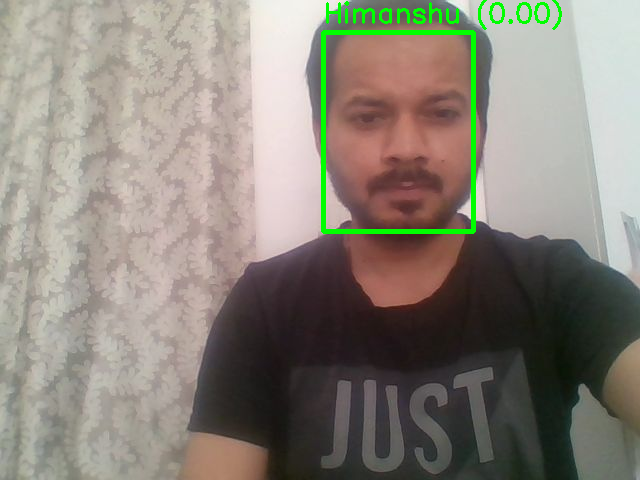


 Lab completed!


In [11]:
# 1. Ask the user for their name
student_name = input("\nEnter your name to register: ")

# 2. Take a photo to save to the database
register_face_from_webcam(student_name)

# 3. Take a second photo to test the AI
test_recognition_from_webcam()

print("\n Lab completed!")
